In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation # import simulation class 
from qclab.models import SpinBoson, AdiabaticSpinBoson # import model class 
from qclab.algorithms import MeanField, AdiabaticMeanField # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver

100%|██████████| 3001/3001 [00:00<00:00, 10587.11it/s]


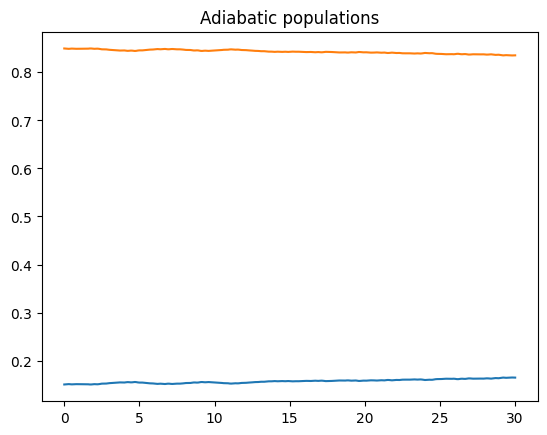

In [6]:
sim = Simulation()

sim.settings.num_trajs = 200
sim.settings.batch_size = 50
sim.settings.tmax = 30
sim.settings.dt_update = 0.01

sim.model = SpinBoson({
    'V':0.5,
    'E':0.5,
    'A':100,
    'W':0.1,
    'l_reorg':0.005,
    'boson_mass':1.0,
    'kBT':1.0,
})
sim.algorithm = MeanField()

def calc_adb_pops(sim, state, parameters):
    h = state["h_q_tot"]
    evals, evecs = np.linalg.eigh(h)
    wf_adb = np.einsum('tia,ti->ta', evecs.conj(), state["wf_db"])
    state["output_dict"]["adb_pops"] = np.abs(wf_adb)**2
    return state, parameters

sim.algorithm.collect_recipe.append(calc_adb_pops)

sim.initial_state["wf_db"]= np.array([1,0], dtype=complex)

data = serial_driver(sim)

t = data.data_dict['t']
pops_adb = np.real(data.data_dict['adb_pops'])
plt.plot(t, pops_adb)
plt.title('Adiabatic populations')
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation # import simulation class 
from qclab.models import SpinBoson, AdiabaticSpinBoson # import model class 
from qclab.algorithms import MeanField, AdiabaticMeanField, AbInitioMeanField # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver


sim = Simulation()

sim.settings.num_trajs = 1
sim.settings.batch_size = 50
sim.settings.tmax = 30
sim.settings.dt_update = 0.0001
sim.settings.dt_collect = sim.settings.dt_update

sim.model = AdiabaticSpinBoson({
    'V':0.5,
    'E':0.5,
    'A':100,
    'W':0.1,
    'l_reorg':0.005,
    'boson_mass':1.0,
    'kBT':1.0,
})
sim.algorithm = AbInitioMeanField()#AdiabaticMeanField({"update_wf_adb_eig_num_substeps":1})#


sim.initial_state["wf_adb"]= np.array([1,1], dtype=complex)/np.sqrt(2)

data = serial_driver(sim)

# t = data.data_dict['t']
# pops_adb = np.real(np.einsum('ti->ti', data.data_dict['adb_pops']))
# plt.plot(t, pops_adb)
# plt.title('Adiabatic populations')
# plt.show()

100%|██████████| 300001/300001 [03:19<00:00, 1505.49it/s]


In [11]:
print(etot-etot[0])

[0.00000000e+00 1.92514230e-04 3.83809469e-04 ... 1.10534182e+01
 1.10538660e+01 1.10543337e+01]


In [14]:
print(etot-etot[0])

[0.00000000e+00 1.93023773e-06 3.85868798e-06 ... 3.60279283e-01
 3.60279903e-01 3.60280524e-01]


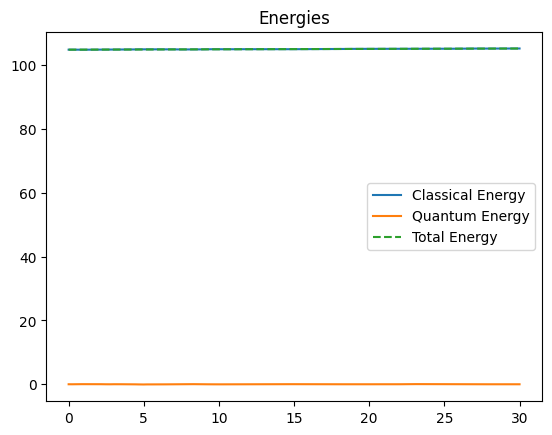

In [15]:

t = data.data_dict['t']
ec = data.data_dict['classical_energy']
eq = data.data_dict['quantum_energy']
etot = ec + eq
plt.plot(t, ec-0*ec[0], label='Classical Energy')
plt.plot(t, eq-0*eq[0], label='Quantum Energy')
plt.plot(t, etot-0*etot[0], label='Total Energy', linestyle='--')
plt.legend()
plt.title('Energies')
plt.show()